# Workshop 3 — Notebook 1: Data Quality Findings
**Course:** Data Analysis Programming 2026-I  
**Topic:** Real Madrid Public Opinion & Sentiment Analysis  
**Purpose:** Descriptive statistics, null rates, outlier analysis, and text length distributions from Silver Parquet files using Pandas. Results justify the governance KPIs computed in the Gold DAG.

## 1. Setup

In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install pyarrow == 11.0.0 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '=': Expected package name at the start of dependency specifier
    =
    ^
Hint: = is not a valid operator. Did you mean == ?


In [3]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Paths ─────────────────────────────────────────────────────────────────
SILVER_PATH = r"C:\Users\Esteban\Documents\Data_analysis\Project\datalake_silver"

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded.')

Libraries loaded.


## 2. Load Silver Parquet Files

In [4]:
# ── Reddit Silver ─────────────────────────────────────────────────────────
reddit_files = sorted(glob.glob(os.path.join(SILVER_PATH, 'reddit_api_realmadrid_*.parquet')))
print(f'Reddit Parquet files found: {len(reddit_files)}')
for f in reddit_files:
    print(f'  {os.path.basename(f)}')

df_reddit = pd.concat(
    [pd.read_parquet(f) for f in reddit_files],
    ignore_index=True
) if reddit_files else pd.DataFrame()

# ── Scraping Silver ───────────────────────────────────────────────────────
scraping_files = sorted(glob.glob(os.path.join(SILVER_PATH, 'web_scraping_realmadrid_*.parquet')))
print(f'\nScraping Parquet files found: {len(scraping_files)}')
for f in scraping_files:
    print(f'  {os.path.basename(f)}')

df_scraping = pd.concat(
    [pd.read_parquet(f) for f in scraping_files],
    ignore_index=True
) if scraping_files else pd.DataFrame()

print(f'\nReddit records   : {len(df_reddit)}')
print(f'Scraping records : {len(df_scraping)}')

Reddit Parquet files found: 2
  reddit_api_realmadrid_20260525_204248.parquet
  reddit_api_realmadrid_20260525_204323.parquet

Scraping Parquet files found: 3
  web_scraping_realmadrid_20260524_231342.parquet
  web_scraping_realmadrid_20260525_000018.parquet
  web_scraping_realmadrid_20260525_203056.parquet

Reddit records   : 38
Scraping records : 60


## 3. Schema Overview

In [5]:
print('=== REDDIT SCHEMA ===')
print(df_reddit.dtypes)
print(f'\nShape: {df_reddit.shape}')

=== REDDIT SCHEMA ===
url                                  str
title                                str
author                               str
published_at         datetime64[us, UTC]
body_text                            str
body_text_clean                      str
title_clean                          str
body_text_missing                   bool
score                            float64
num_comments                     float64
subreddit                            str
source                               str
bronze_source                        str
dtype: object

Shape: (38, 13)


In [6]:
print('=== SCRAPING SCHEMA ===')
print(df_scraping.dtypes)
print(f'\nShape: {df_scraping.shape}')

=== SCRAPING SCHEMA ===
url                                  str
title                                str
author                               str
published_at         datetime64[us, UTC]
reading_time_min                   int64
body_text                            str
body_text_clean                      str
title_clean                          str
body_text_missing                   bool
source                               str
bronze_source                        str
dtype: object

Shape: (60, 11)


## 4. Null Rate Analysis
**Justification for governance KPI `null_rate_*`:** Every field with a non-zero null rate observed here is included as a governance KPI in the Gold DAG.

In [7]:
def null_rate_table(df, source_name):
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    table = pd.DataFrame({
        'null_count': null_counts,
        'null_pct':   null_pct,
        'dtype':      df.dtypes
    }).sort_values('null_pct', ascending=False)
    print(f'\n=== NULL RATES — {source_name} ===')
    display(table)
    return table

null_reddit   = null_rate_table(df_reddit,   'REDDIT')
null_scraping = null_rate_table(df_scraping, 'SCRAPING')


=== NULL RATES — REDDIT ===


,null_count,null_pct,dtype
url,0,0.0,str
title,0,0.0,str
author,0,0.0,str
published_at,0,0.0,"datetime64[us, UTC]"
body_text,0,0.0,str
body_text_clean,0,0.0,str
title_clean,0,0.0,str
body_text_missing,0,0.0,bool
score,0,0.0,float64
num_comments,0,0.0,float64



=== NULL RATES — SCRAPING ===


,null_count,null_pct,dtype
url,0,0.0,str
title,0,0.0,str
author,0,0.0,str
published_at,0,0.0,"datetime64[us, UTC]"
reading_time_min,0,0.0,int64
body_text,0,0.0,str
body_text_clean,0,0.0,str
title_clean,0,0.0,str
body_text_missing,0,0.0,bool
source,0,0.0,str


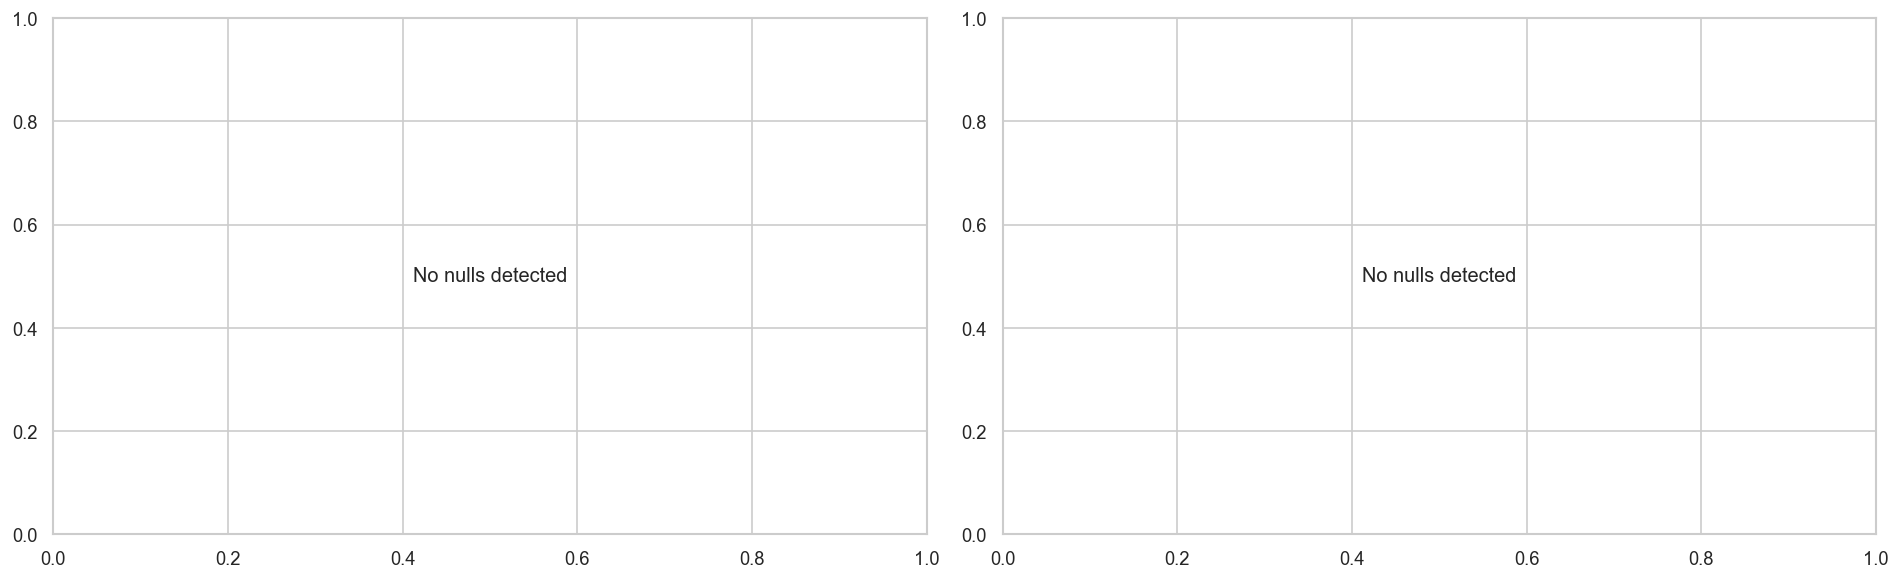

Figure saved: null_rates_comparison.png


In [8]:
# ── Visual: Null rate comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, table, title in zip(axes,
                            [null_reddit, null_scraping],
                            ['Reddit (API)', 'Web Scraping']):
    data = table[table['null_pct'] > 0]
    if data.empty:
        ax.text(0.5, 0.5, 'No nulls detected', ha='center', va='center')
    else:
        ax.barh(data.index, data['null_pct'], color='steelblue', edgecolor='white')
        ax.set_xlabel('Null Rate (%)')
        ax.set_title(f'Null Rate per Column — {title}')
        for i, v in enumerate(data['null_pct']):
            ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('null_rates_comparison.png', bbox_inches='tight')
plt.show()
print('Figure saved: null_rates_comparison.png')

## 5. Duplicate Analysis
**Justification for governance KPI `duplicate_rate`:** Duplication across ingestion runs is a known risk when the same posts appear in multiple daily Bronze files.

In [9]:
def duplicate_report(df, source_name, key_col='url'):
    total      = len(df)
    duplicates = df.duplicated(subset=[key_col]).sum()
    rate       = round(duplicates / total * 100, 2)
    print(f'[{source_name}]')
    print(f'  Total records    : {total}')
    print(f'  Duplicate rows   : {duplicates}')
    print(f'  Duplicate rate   : {rate}%')
    return {'source': source_name, 'total': total,
            'duplicates': duplicates, 'duplicate_rate_pct': rate}

dup_reddit   = duplicate_report(df_reddit,   'Reddit')
dup_scraping = duplicate_report(df_scraping, 'Scraping')

[Reddit]
  Total records    : 38
  Duplicate rows   : 19
  Duplicate rate   : 50.0%
[Scraping]
  Total records    : 60
  Duplicate rows   : 40
  Duplicate rate   : 66.67%


## 6. Body Text Missing Rate
**Justification for governance KPI `body_text_missing_rate`:** Reddit posts often have no body text (title-only posts). This finding determines the fallback strategy used in the VADER analysis (title as fallback when body is empty).

In [10]:
if 'body_text_missing' in df_reddit.columns:
    reddit_missing = df_reddit['body_text_missing'].sum()
    reddit_missing_pct = round(reddit_missing / len(df_reddit) * 100, 2)
    print(f'Reddit — posts without body text: {reddit_missing} ({reddit_missing_pct}%)')

if 'body_text_missing' in df_scraping.columns:
    scraping_missing = df_scraping['body_text_missing'].sum()
    scraping_missing_pct = round(scraping_missing / len(df_scraping) * 100, 2)
    print(f'Scraping — articles without body text: {scraping_missing} ({scraping_missing_pct}%)')

Reddit — posts without body text: 16 (42.11%)
Scraping — articles without body text: 0 (0.0%)


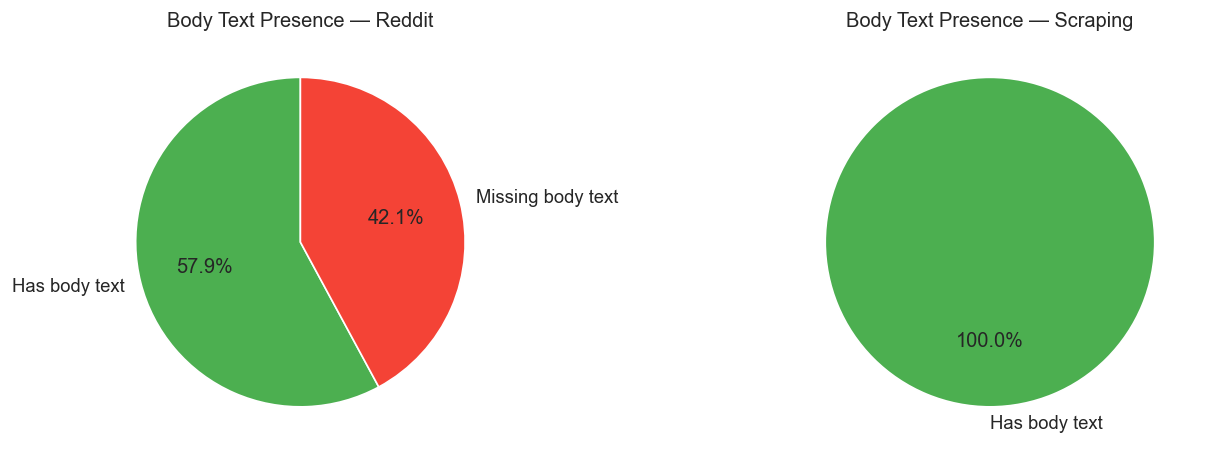

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes,
                          [df_reddit, df_scraping],
                          ['Reddit', 'Scraping']):
    if 'body_text_missing' in df.columns:
        counts = df['body_text_missing'].value_counts()
        
        # Construir labels dinámicamente según los valores presentes
        label_map = {True: 'Missing body text', False: 'Has body text'}
        labels = [label_map[k] for k in counts.index]
        colors = ['#F44336' if k else '#4CAF50' for k in counts.index]
        
        ax.pie(counts, labels=labels, autopct='%1.1f%%',
               colors=colors, startangle=90)
        ax.set_title(f'Body Text Presence — {title}')

plt.tight_layout()
plt.savefig('body_text_missing.png', bbox_inches='tight')
plt.show()

## 7. Outlier Analysis — Numeric Fields
**Justification for governance KPIs `outlier_rate_score`, `outlier_rate_num_comments`, `outlier_rate_reading_time_min`:** Viral Reddit posts with extreme scores distort engagement analysis. Outlier capping via IQR was applied in both Silver DAGs.

In [13]:
def iqr_outlier_analysis(series, col_name, source_name):
    s = series.dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((s < lower) | (s > upper)).sum()
    pct = round(n_outliers / len(s) * 100, 2)

    print(f'[{source_name}] {col_name}')
    print(f'  mean={s.mean():.2f} | median={s.median():.2f} | std={s.std():.2f}')
    print(f'  Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}')
    print(f'  Bounds: [{lower:.2f}, {upper:.2f}]')
    print(f'  Outliers: {n_outliers} ({pct}%)')
    return {'lower': lower, 'upper': upper, 'n_outliers': n_outliers, 'pct': pct}

print('=== REDDIT OUTLIER ANALYSIS ===')
stats_score = iqr_outlier_analysis(df_reddit['score'],        'score',        'Reddit')
stats_nc    = iqr_outlier_analysis(df_reddit['num_comments'], 'num_comments', 'Reddit')

print('\n=== SCRAPING OUTLIER ANALYSIS ===')
if 'reading_time_min' in df_scraping.columns:
    stats_rt = iqr_outlier_analysis(df_scraping['reading_time_min'], 'reading_time_min', 'Scraping')

=== REDDIT OUTLIER ANALYSIS ===
[Reddit] score
  mean=3.39 | median=1.00 | std=3.91
  Q1=1.00 | Q3=5.75 | IQR=4.75
  Bounds: [-6.12, 12.88]
  Outliers: 0 (0.0%)
[Reddit] num_comments
  mean=3.70 | median=1.00 | std=4.99
  Q1=0.00 | Q3=7.25 | IQR=7.25
  Bounds: [-10.88, 18.12]
  Outliers: 0 (0.0%)

=== SCRAPING OUTLIER ANALYSIS ===
[Scraping] reading_time_min
  mean=2.00 | median=2.00 | std=0.00
  Q1=2.00 | Q3=2.00 | IQR=0.00
  Bounds: [2.00, 2.00]
  Outliers: 0 (0.0%)


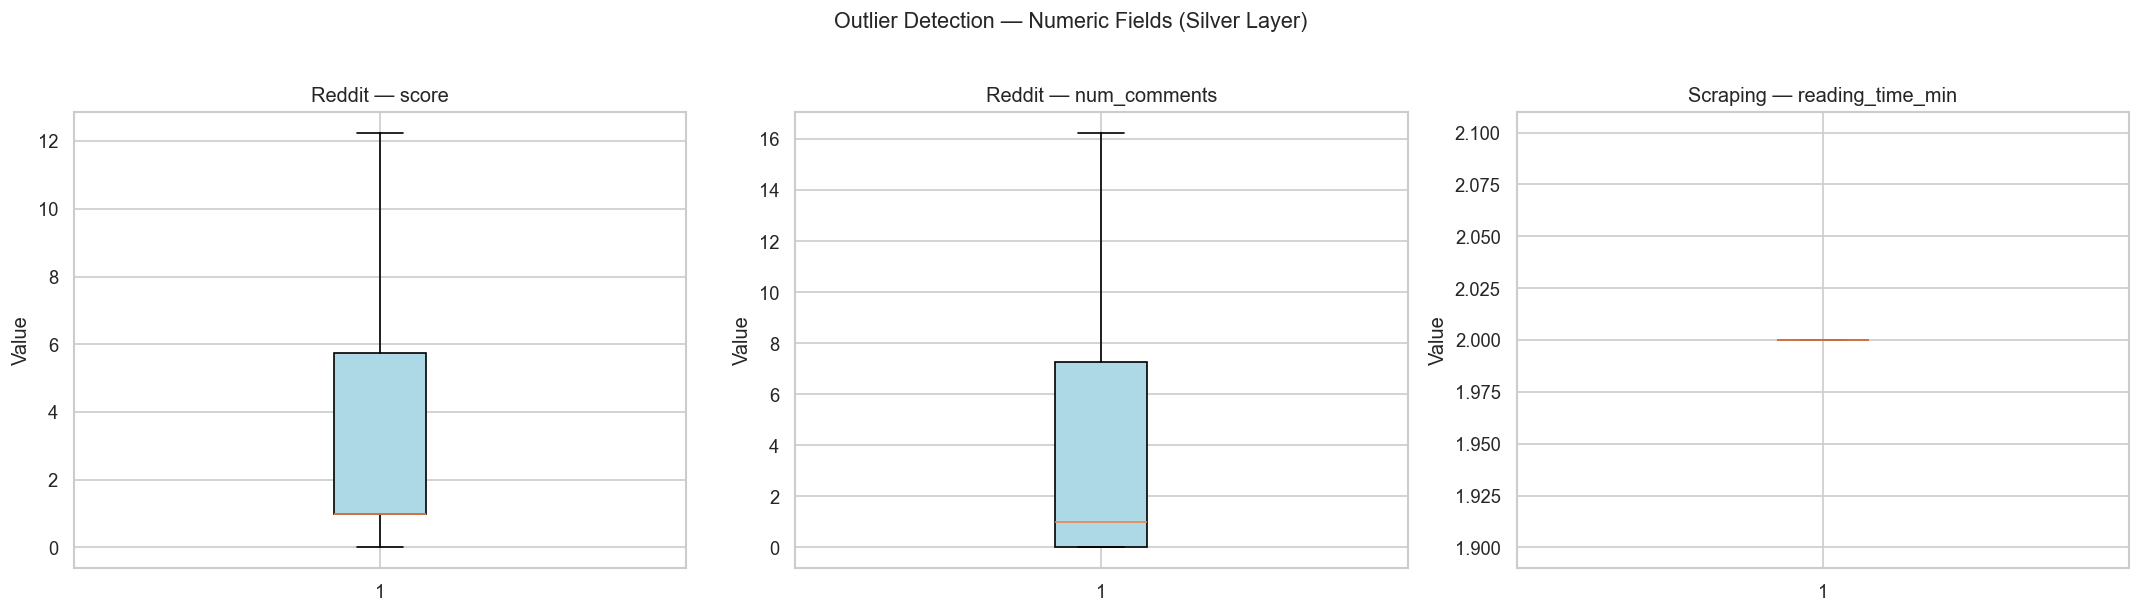

In [14]:
# ── Visual: Boxplots before/after IQR capping ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, series, title in zip(
    axes,
    [df_reddit['score'], df_reddit['num_comments'],
     df_scraping['reading_time_min'] if 'reading_time_min' in df_scraping.columns else pd.Series()],
    ['Reddit — score', 'Reddit — num_comments', 'Scraping — reading_time_min']
):
    if series.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        continue
    ax.boxplot(series.dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(title)
    ax.set_ylabel('Value')

plt.suptitle('Outlier Detection — Numeric Fields (Silver Layer)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', bbox_inches='tight')
plt.show()

outliers_20260409_000909.png


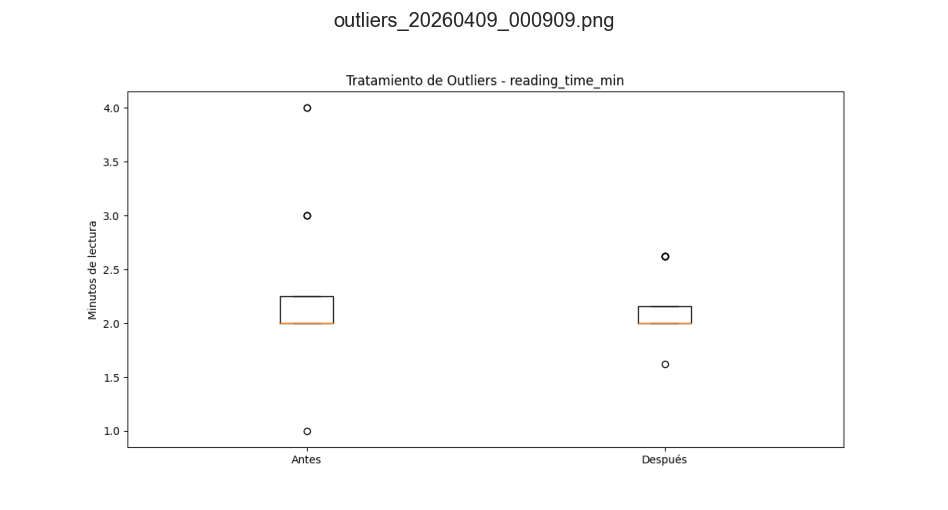

outliers_20260409_230849.png


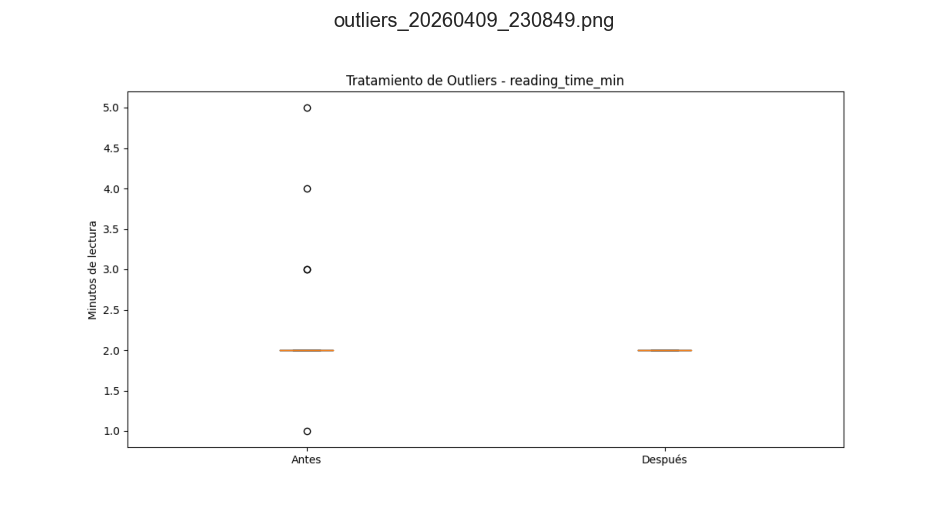

outliers_20260409_234011.png


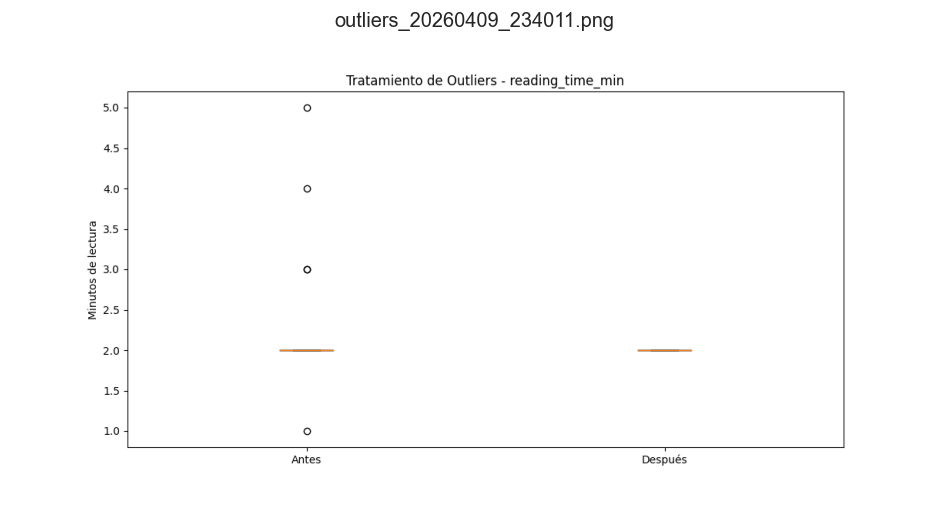

outliers_20260409_234015.png


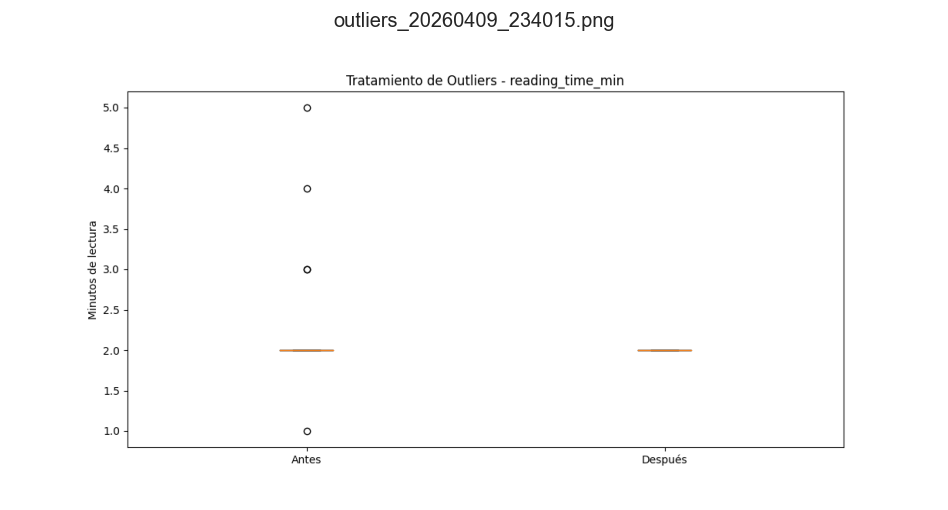

outliers_20260409_234520.png


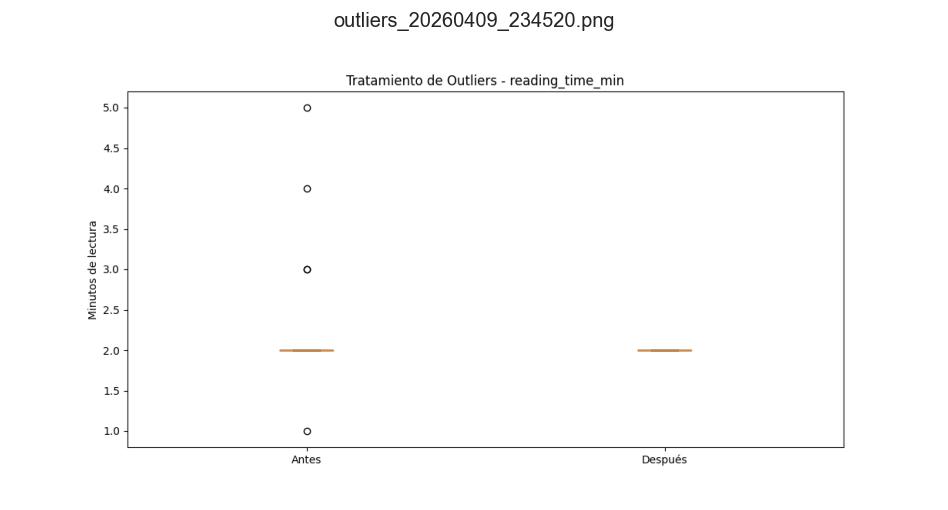

outliers_20260409_234523.png


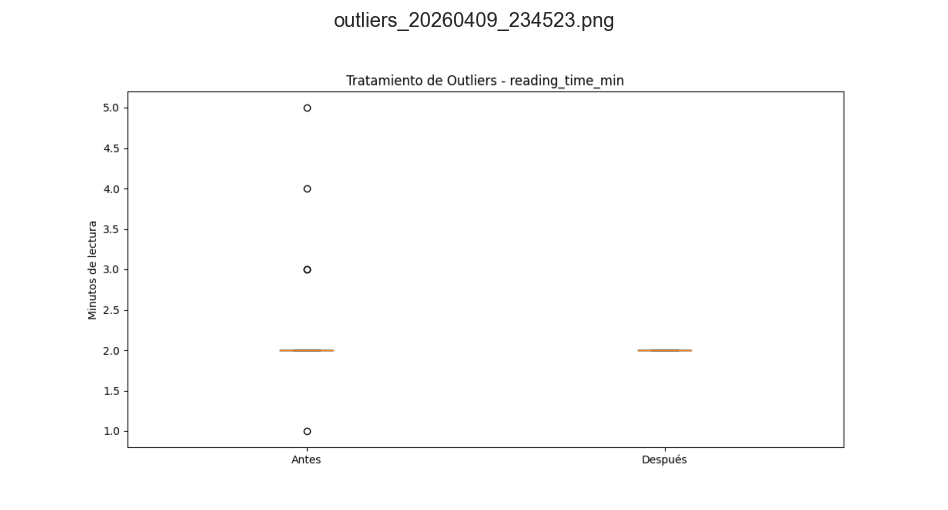

outliers_20260410_000016.png


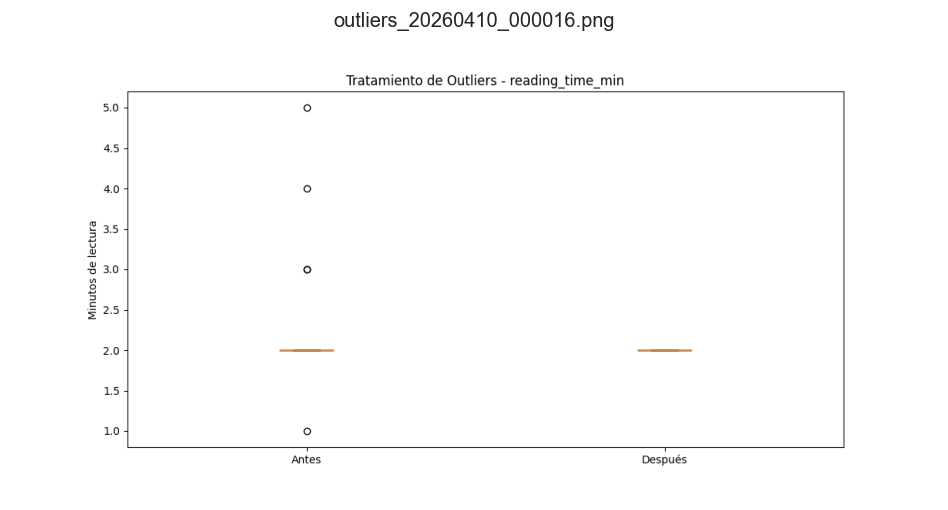

outliers_20260410_022822.png


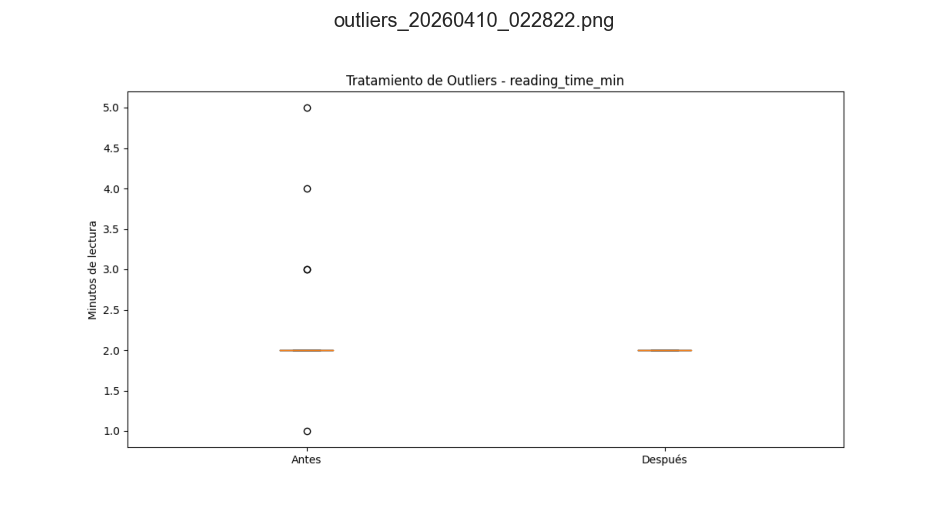

outliers_20260410_022852.png


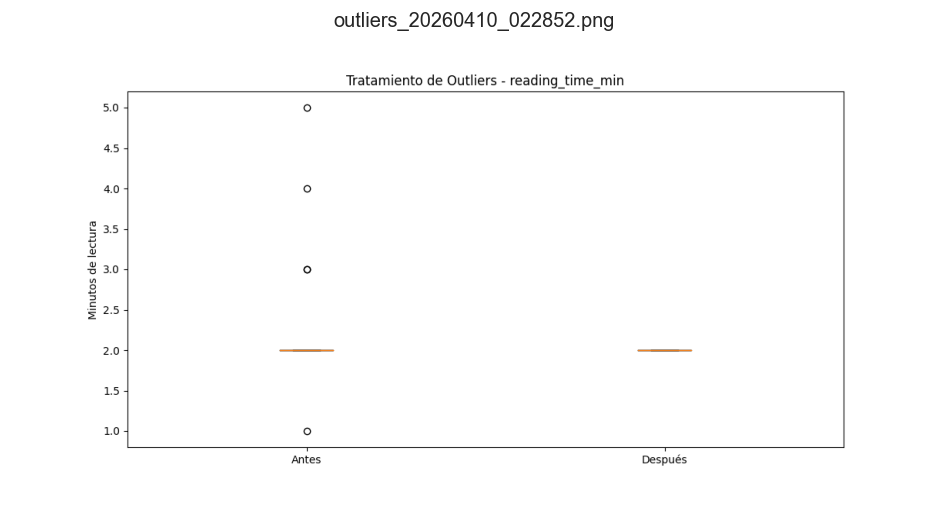

outliers_20260410_023925.png


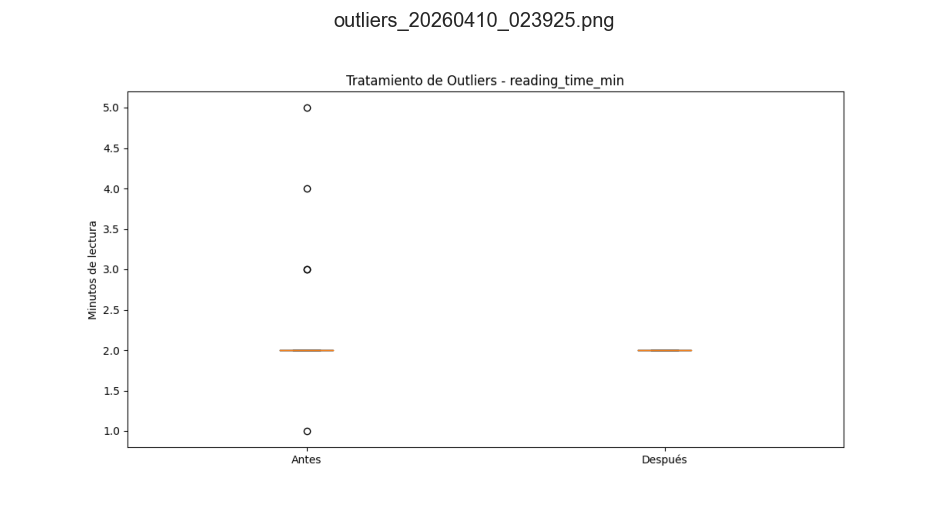

outliers_20260410_024350.png


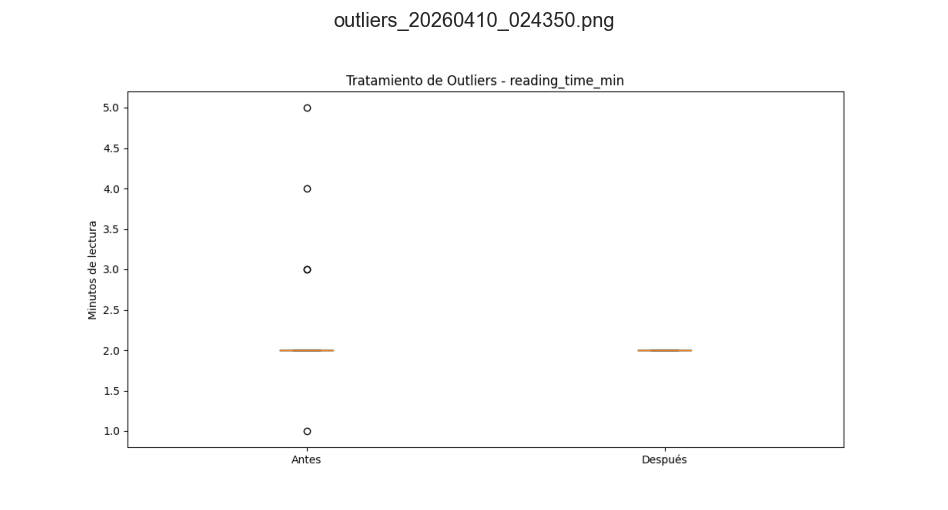

outliers_20260410_024501.png


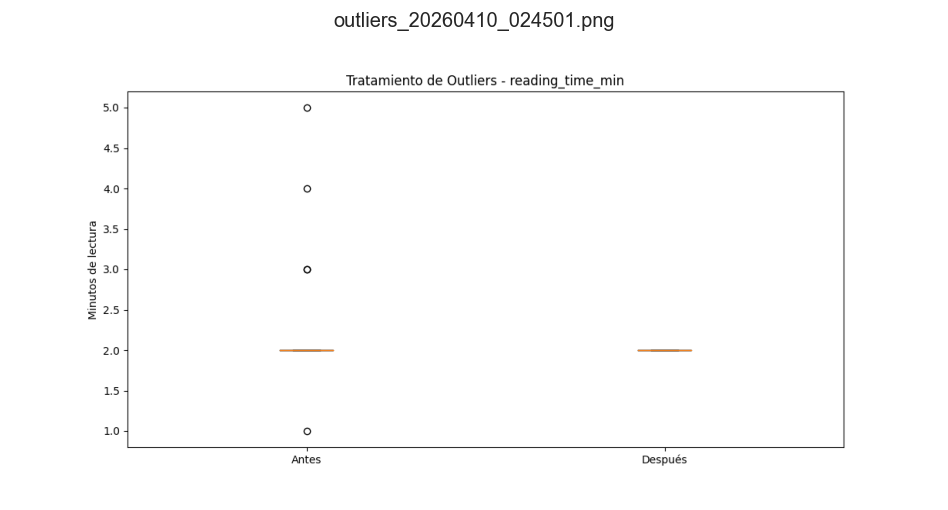

outliers_20260410_024852.png


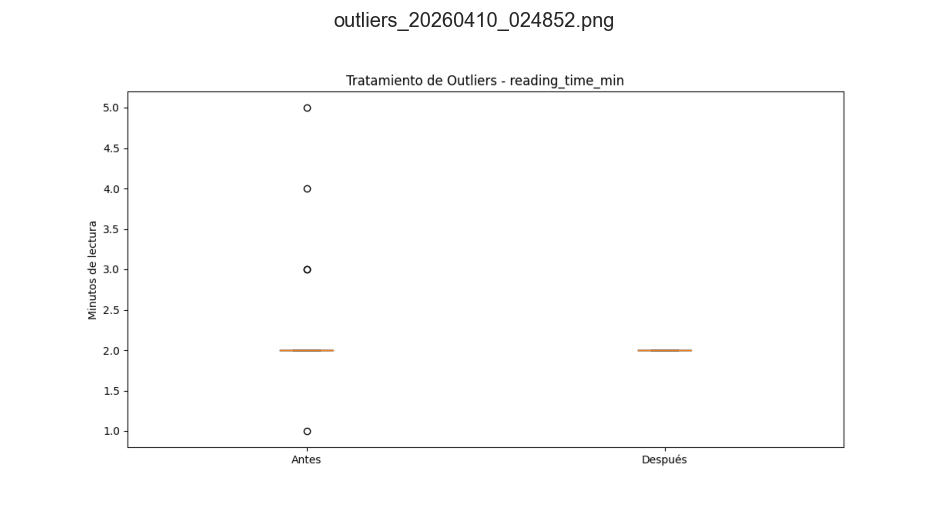

outliers_20260410_025204.png


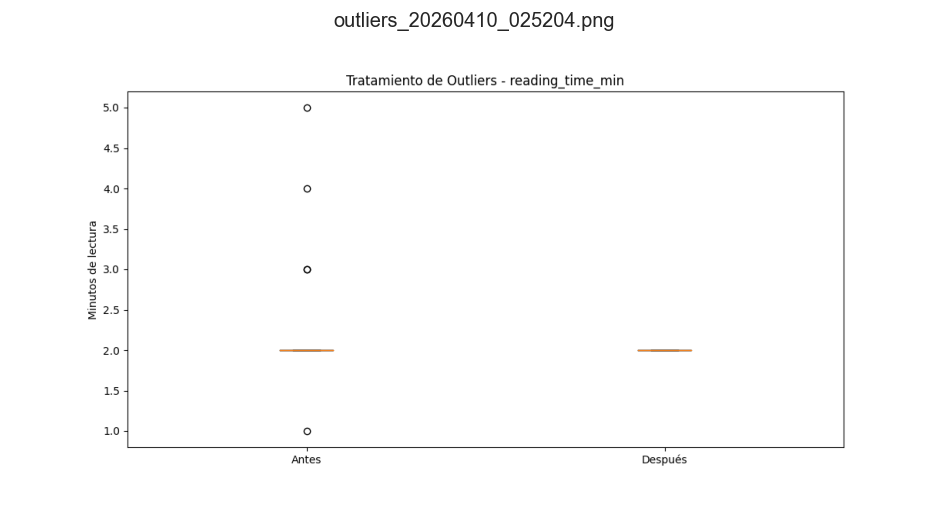

outliers_20260411_013920.png


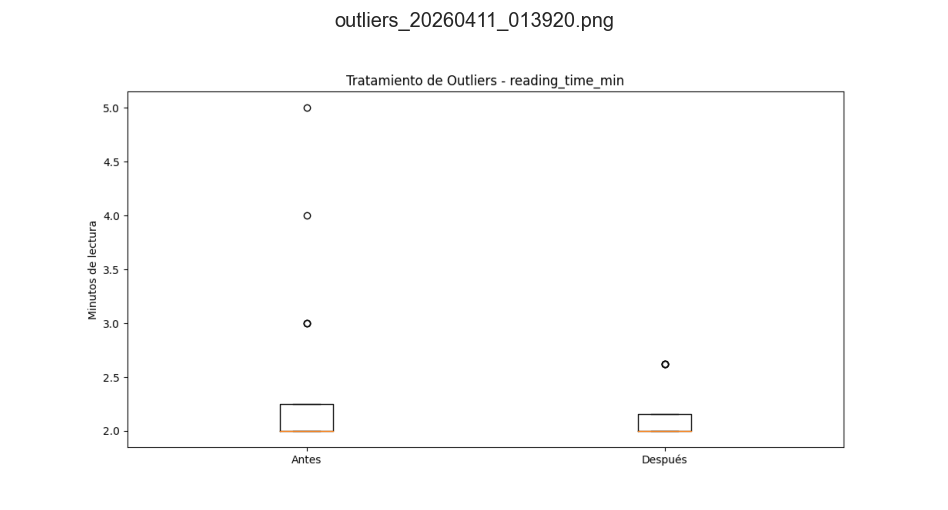

outliers_20260411_014010.png


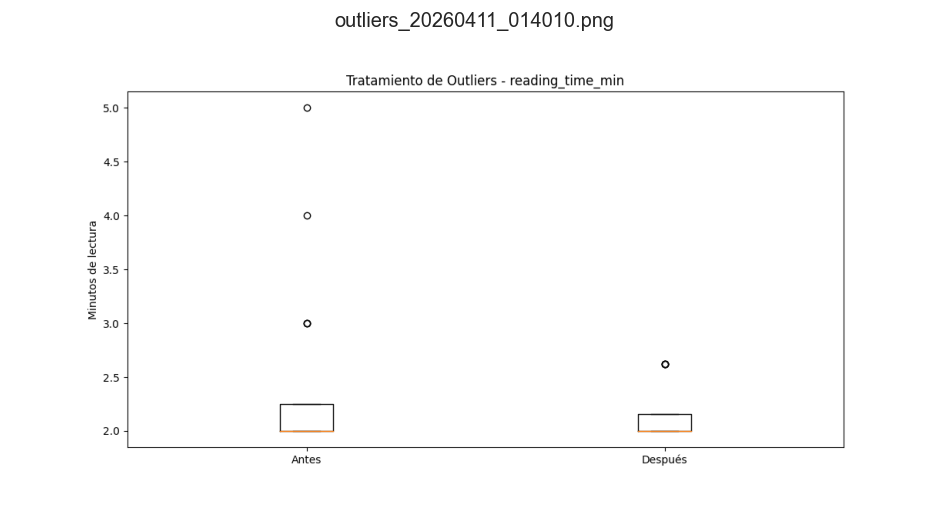

outliers_20260411_014040.png


KeyboardInterrupt: 

In [22]:
import matplotlib.image as mpimg

report_path = os.path.join(SILVER_PATH, "outlier_reports")
png_files = sorted(glob.glob(os.path.join(report_path, "outliers_*.png")))

for img_path in png_files:
    print(os.path.basename(img_path))
    img = mpimg.imread(img_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.basename(img_path))
    plt.show()

## 8. Text Length Distribution
**Justification for governance KPIs `text_length_mean`, `text_length_median`, `text_length_min`, `text_length_max`:** Text length is a proxy for content depth. Short texts (< 50 chars) after cleaning indicate near-empty content and are flagged.

In [15]:
def text_length_stats(df, col, source_name):
    lengths = df[col].dropna().apply(len)
    print(f'[{source_name}] {col} length stats:')
    print(lengths.describe().to_string())
    return lengths

print('=== TEXT LENGTH ANALYSIS ===')
len_reddit_body   = text_length_stats(df_reddit,   'body_text_clean', 'Reddit')
print()
len_scraping_body = text_length_stats(df_scraping, 'body_text_clean', 'Scraping')

=== TEXT LENGTH ANALYSIS ===
[Reddit] body_text_clean length stats:
count       38.000000
mean      2042.947368
std       4553.166958
min          0.000000
25%          0.000000
50%        249.000000
75%        745.750000
max      17708.000000

[Scraping] body_text_clean length stats:
count      60.000000
mean     1726.450000
std       506.681173
min       712.000000
25%      1599.000000
50%      1753.500000
75%      1998.000000
max      2631.000000


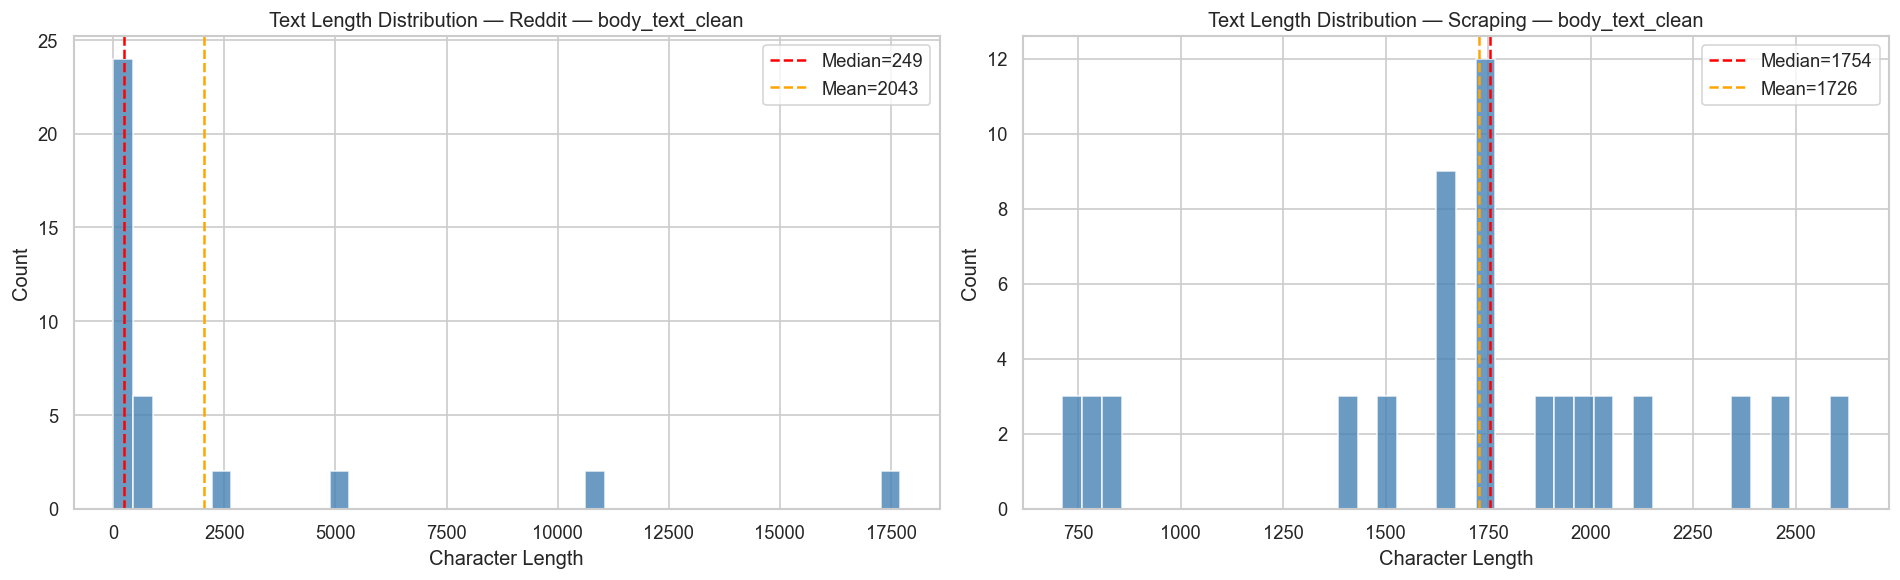

In [16]:
# ── Visual: Text length histograms ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, lengths, title in zip(axes,
                               [len_reddit_body, len_scraping_body],
                               ['Reddit — body_text_clean', 'Scraping — body_text_clean']):
    ax.hist(lengths.clip(upper=lengths.quantile(0.99)), bins=40,
            color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(lengths.median(), color='red', linestyle='--', label=f'Median={lengths.median():.0f}')
    ax.axvline(lengths.mean(),   color='orange', linestyle='--', label=f'Mean={lengths.mean():.0f}')
    ax.set_xlabel('Character Length')
    ax.set_ylabel('Count')
    ax.set_title(f'Text Length Distribution — {title}')
    ax.legend()

plt.tight_layout()
plt.savefig('text_length_distribution.png', bbox_inches='tight')
plt.show()

In [17]:
# ── Very short texts (< 50 chars) ─────────────────────────────────────────
threshold = 50
reddit_short   = (len_reddit_body   < threshold).sum()
scraping_short = (len_scraping_body < threshold).sum()

print(f'Reddit   — texts shorter than {threshold} chars: {reddit_short} ({reddit_short/len(df_reddit)*100:.1f}%)')
print(f'Scraping — texts shorter than {threshold} chars: {scraping_short} ({scraping_short/len(df_scraping)*100:.1f}%)')

Reddit   — texts shorter than 50 chars: 16 (42.1%)
Scraping — texts shorter than 50 chars: 0 (0.0%)


## 9. Volume by Bronze Source (Ingestion Frequency)
**Justification for governance KPI `ingestion_frequency_compliance`:** Each unique bronze_source file represents one DAG run. Comparing actual runs vs expected runs (@daily = 7/week) shows pipeline reliability.

In [18]:
if 'bronze_source' in df_reddit.columns:
    reddit_runs = df_reddit['bronze_source'].value_counts().sort_index()
    print(f'Reddit — unique bronze_source files: {len(reddit_runs)}')
    print(reddit_runs.to_string())

if 'bronze_source' in df_scraping.columns:
    scraping_runs = df_scraping['bronze_source'].value_counts().sort_index()
    print(f'\nScraping — unique bronze_source files: {len(scraping_runs)}')
    print(scraping_runs.to_string())

Reddit — unique bronze_source files: 1
bronze_source
reddit_api_realmadrid_20260525_203054.json    38

Scraping — unique bronze_source files: 3
bronze_source
web_scraping_realmadrid_20260524_230629.json    20
web_scraping_realmadrid_20260524_231346.json    20
web_scraping_realmadrid_20260525_000021.json    20


## 10. Schema Compliance
**Justification for governance KPI `schema_compliance_rate`:** Records with all required fields present are schema-compliant. Missing required fields indicate ingestion issues.

In [25]:
REQUIRED_COLS = ['url', 'title', 'author', 'published_at', 'body_text', 'source']

for df, name in [(df_reddit, 'Reddit'), (df_scraping, 'Scraping')]:
    existing = [c for c in REQUIRED_COLS if c in df.columns]
    compliant = df[existing].notnull().all(axis=1).sum()
    rate = round(compliant / len(df) * 100, 2)
    print(f'[{name}] Schema compliance rate: {compliant}/{len(df)} = {rate}%')

[Reddit] Schema compliance rate: 38/38 = 100.0%
[Scraping] Schema compliance rate: 60/60 = 100.0%
